# Chapter 125 — Vector Addition

> **Prerequisites:** What is a Vector? (ch121), Geometric Interpretation (ch122), Vectors in Programming (ch123)
> **You will learn:**
> - The geometric definition of vector addition (tip-to-tail)
> - The algebraic definition (component-wise)
> - The commutativity and associativity of vector addition
> - Practical applications in physics and data science

> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

Vector addition combines two vectors into a third. Geometrically: place the tail of the second vector at the head of the first. The sum is the arrow from the tail of the first to the head of the second.

Algebraically: add corresponding components.

$$\mathbf{u} + \mathbf{v} = \begin{pmatrix} u_1 + v_1 \\ u_2 + v_2 \\ \vdots \\ u_n + v_n \end{pmatrix}$$

Both definitions produce the same result. The geometric version provides intuition. The algebraic version provides computation.

**Common misconceptions:**
- You can only add vectors of the same dimension. Adding a 2D and 3D vector is undefined.
- Vector addition is not the same as concatenation. `[1,2] + [3,4]` = `[4,6]`, not `[1,2,3,4]`.

---

## 2. Intuition & Mental Models

**Displacement model:** If **u** means "walk 3 east and 1 north" and **v** means "walk 2 west and 4 north", then **u** + **v** means "walk the combined displacement" = "walk 1 east and 5 north". Order does not matter — the final position is the same.

**Force model:** Two forces acting on an object simultaneously produce a net force equal to their vector sum. This is directly why vector addition is the foundation of Newtonian physics.

**Data model:** Adding two user preference vectors in a recommendation system computes a "combined preference". The same operation powers a lot of ML.

Recall from ch122 (Geometric Interpretation) that the triangle law holds: $\overrightarrow{AB} + \overrightarrow{BC} = \overrightarrow{AC}$. That is vector addition.

---

## 3. Visualization

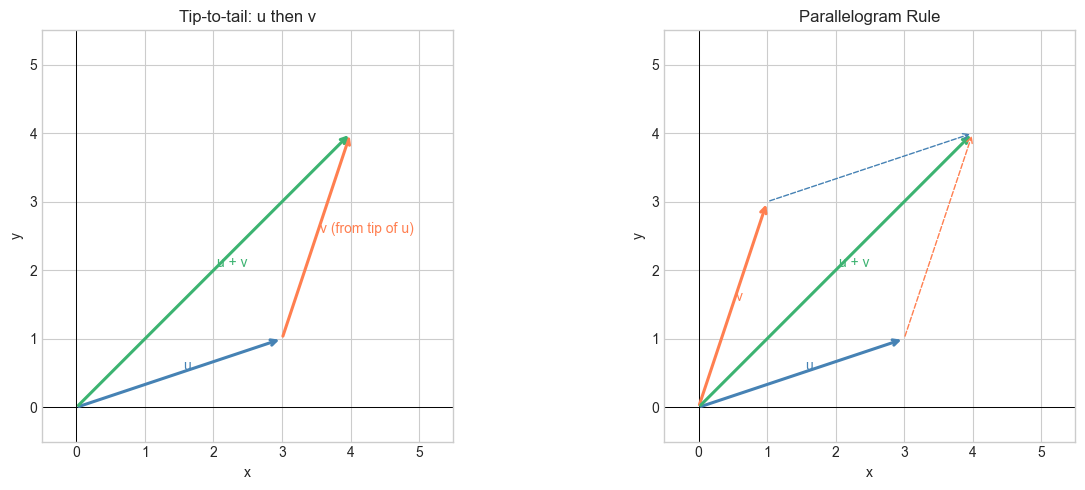

In [1]:
# --- Visualization: Geometric vector addition (tip-to-tail and parallelogram) ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

u = np.array([3.0, 1.0])
v = np.array([1.0, 3.0])
w = u + v  # the sum

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ---- Left: tip-to-tail ----
ax = axes[0]
O = np.array([0, 0])
arrows = [
    (O, u, 'steelblue',      'u'),
    (u, v, 'coral',          'v (from tip of u)'),
    (O, w, 'mediumseagreen', 'u + v'),
]
for start, vec, color, label in arrows:
    ax.annotate('', xy=start + vec, xytext=start,
                arrowprops=dict(arrowstyle='->', color=color, lw=2.2))
    mid = start + vec * 0.5
    ax.text(mid[0]+0.05, mid[1]+0.05, label, color=color, fontsize=10)
ax.set_xlim(-0.5, 5.5); ax.set_ylim(-0.5, 5.5)
ax.axhline(0, color='black', lw=0.7); ax.axvline(0, color='black', lw=0.7)
ax.set_aspect('equal')
ax.set_title('Tip-to-tail: u then v')
ax.set_xlabel('x'); ax.set_ylabel('y')

# ---- Right: parallelogram rule ----
ax = axes[1]
for start, vec, color, label in [
    (O, u, 'steelblue', 'u'),
    (O, v, 'coral',     'v'),
    (O, w, 'mediumseagreen', 'u + v'),
]:
    ax.annotate('', xy=start + vec, xytext=start,
                arrowprops=dict(arrowstyle='->', color=color, lw=2.2))
    mid = start + vec * 0.5
    ax.text(mid[0]+0.05, mid[1]+0.05, label, color=color, fontsize=10)

# Draw dashed completing sides
ax.annotate('', xy=w, xytext=u,
            arrowprops=dict(arrowstyle='->', color='coral', lw=1, linestyle='dashed'))
ax.annotate('', xy=w, xytext=v,
            arrowprops=dict(arrowstyle='->', color='steelblue', lw=1, linestyle='dashed'))

ax.set_xlim(-0.5, 5.5); ax.set_ylim(-0.5, 5.5)
ax.axhline(0, color='black', lw=0.7); ax.axvline(0, color='black', lw=0.7)
ax.set_aspect('equal')
ax.set_title('Parallelogram Rule')
ax.set_xlabel('x'); ax.set_ylabel('y')

plt.tight_layout()
plt.show()

## 4. Mathematical Formulation

**Definition.** For **u**, **v** ∈ ℝⁿ:

$$(\mathbf{u} + \mathbf{v})_i = u_i + v_i \qquad \text{for } i = 1, \ldots, n$$

**Properties:**
- **Commutativity:** $\mathbf{u} + \mathbf{v} = \mathbf{v} + \mathbf{u}$
- **Associativity:** $(\mathbf{u} + \mathbf{v}) + \mathbf{w} = \mathbf{u} + (\mathbf{v} + \mathbf{w})$
- **Identity:** $\mathbf{v} + \mathbf{0} = \mathbf{v}$
- **Inverse:** $\mathbf{v} + (-\mathbf{v}) = \mathbf{0}$

where $-\mathbf{v} = (-v_1, \ldots, -v_n)$.

In [2]:
# --- Mathematical Formulation: Verify addition properties ---
import numpy as np

u = np.array([1.0, 2.0, 3.0])
v = np.array([4.0, -1.0, 0.5])
w = np.array([-2.0, 3.0, 1.0])

print("u + v =", u + v)
print("v + u =", v + u)
print("Commutative:", np.allclose(u + v, v + u))

print("\n(u+v)+w =", (u + v) + w)
print("u+(v+w) =",   u + (v + w))
print("Associative:", np.allclose((u + v) + w, u + (v + w)))

print("\nv + 0 =", v + np.zeros(3))
print("v + (-v) =", v + (-v))

u + v = [5.  1.  3.5]
v + u = [5.  1.  3.5]
Commutative: True

(u+v)+w = [3.  4.  4.5]
u+(v+w) = [3.  4.  4.5]
Associative: True

v + 0 = [ 4.  -1.   0.5]
v + (-v) = [0. 0. 0.]


## 5. Python Implementation

In [3]:
# --- Implementation: vector addition from scratch ---
import numpy as np

def vector_add(u, v):
    """
    Add two vectors component-wise.

    Args:
        u: ndarray shape (n,)
        v: ndarray shape (n,)

    Returns:
        ndarray shape (n,)

    Raises:
        ValueError: if dimensions differ
    """
    u, v = np.asarray(u, float), np.asarray(v, float)
    if u.shape != v.shape:
        raise ValueError(f"Dimension mismatch: {u.shape} vs {v.shape}")
    result = np.empty_like(u)
    for i in range(len(u)):
        result[i] = u[i] + v[i]  # explicit loop to show the structure
    return result


def vector_subtract(u, v):
    """
    Subtract v from u component-wise.

    Args:
        u, v: ndarray shape (n,)

    Returns:
        ndarray shape (n,)
    """
    return vector_add(u, -np.asarray(v, float))


# Test
u = np.array([1.0, 2.0, 3.0])
v = np.array([4.0, -1.0, 0.5])

result = vector_add(u, v)
print("Our add:", result)
print("NumPy:  ", u + v)
print("Match:  ", np.allclose(result, u + v))

# Dimension mismatch
try:
    vector_add(u, np.array([1.0, 2.0]))
except ValueError as e:
    print("Error:", e)

Our add: [5.  1.  3.5]
NumPy:   [5.  1.  3.5]
Match:   True
Error: Dimension mismatch: (3,) vs (2,)


## 6. Experiments

Steps: 200
Net displacement: 12.858
Total distance:   200
Efficiency:       0.0643


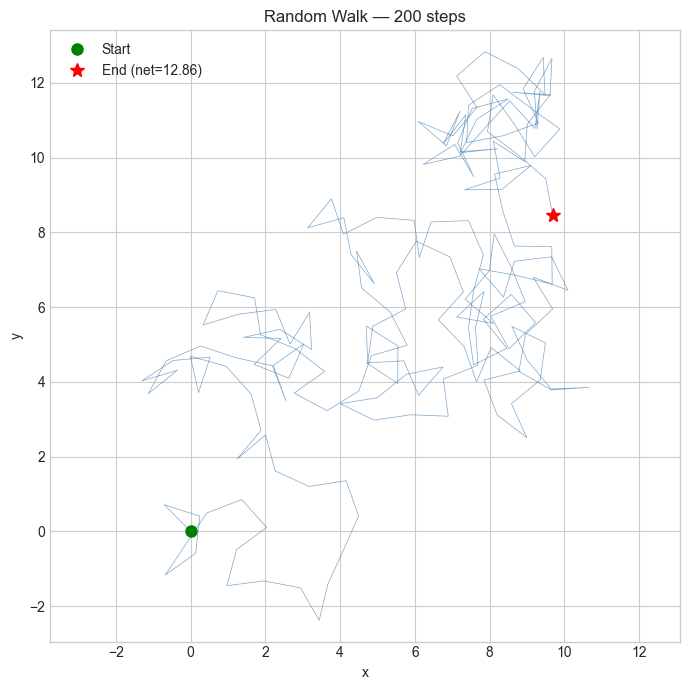

In [4]:
# --- Experiment 1: Net displacement of a random walk ---
# Hypothesis: the sum of random unit-direction steps produces a net displacement
#             that grows much slower than the total distance traveled.
# Try changing: N_STEPS (10, 100, 1000, 10000)
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

N_STEPS = 200  # <-- modify this
np.random.seed(42)

angles = np.random.uniform(0, 2*np.pi, N_STEPS)
steps  = np.column_stack([np.cos(angles), np.sin(angles)])  # unit steps

path = np.vstack([np.zeros(2), np.cumsum(steps, axis=0)])

net_displacement = np.linalg.norm(path[-1])
total_distance   = N_STEPS  # each step has length 1

print(f"Steps: {N_STEPS}")
print(f"Net displacement: {net_displacement:.3f}")
print(f"Total distance:   {total_distance}")
print(f"Efficiency:       {net_displacement/total_distance:.4f}")

plt.figure(figsize=(7, 7))
plt.plot(path[:, 0], path[:, 1], lw=0.5, color='steelblue', alpha=0.7)
plt.plot(*path[0], 'go', markersize=8, label='Start')
plt.plot(*path[-1], 'r*', markersize=10, label=f'End (net={net_displacement:.2f})')
plt.title(f'Random Walk — {N_STEPS} steps')
plt.xlabel('x'); plt.ylabel('y')
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()

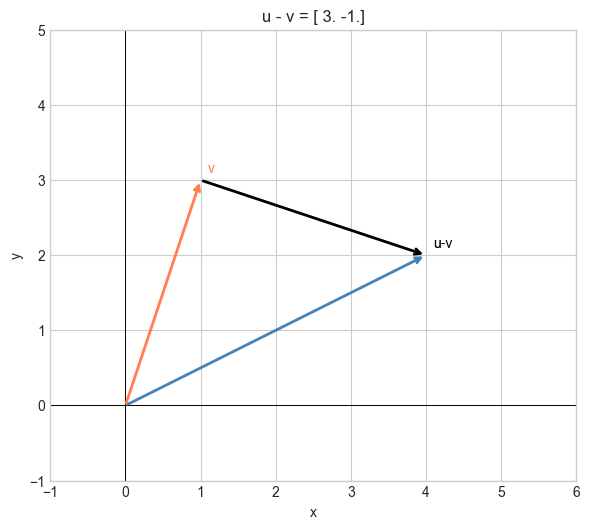

In [5]:
# --- Experiment 2: Vector subtraction as a directed arrow ---
# Hypothesis: u - v points FROM v TO u when both are drawn from the origin.
# Try changing: the vectors u and v.
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

u = np.array([4.0, 2.0])  # <-- modify
v = np.array([1.0, 3.0])  # <-- modify

diff = u - v

fig, ax = plt.subplots(figsize=(6, 6))
for vec, label, color in [(u, 'u', 'steelblue'), (v, 'v', 'coral'), (diff, 'u-v', 'black')]:
    start = np.zeros(2) if label != 'u-v' else v
    ax.annotate('', xy=start+vec if label == 'u-v' else vec, xytext=start,
                arrowprops=dict(arrowstyle='->', color=color, lw=2))
    ax.text((start+vec if label=='u-v' else vec)[0]+0.1,
            (start+vec if label=='u-v' else vec)[1]+0.1, label, color=color)
ax.set_xlim(-1, 6); ax.set_ylim(-1, 5)
ax.axhline(0, color='black', lw=0.7); ax.axvline(0, color='black', lw=0.7)
ax.set_aspect('equal')
ax.set_title(f'u - v = {diff}')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout(); plt.show()

## 7. Exercises

**Easy 1.** Compute **u** + **v** for **u** = (2, −1, 3) and **v** = (−4, 5, 0). Verify with NumPy. *(Expected: (−2, 4, 3))*

**Easy 2.** A particle moves by displacement **d₁** = (3, 4), then **d₂** = (−1, 2), then **d₃** = (2, −6). What is its net displacement from the starting point?

**Medium 1.** Plot the following vector chain geometrically: **a** = (1, 0), **b** = (0, 1), **c** = (−1, 0), **d** = (0, −1). Their sum should be the zero vector. Verify this visually and numerically.

**Medium 2.** Generate 1000 random 2D unit vectors (random angles, magnitude 1). Compute their sum. What is the expected magnitude of the sum? Run 50 trials and plot the distribution of net magnitudes.

**Hard.** Prove algebraically that the midpoint of segment AB can be expressed as $\frac{1}{2}(\mathbf{a} + \mathbf{b})$ where **a** and **b** are position vectors of A and B. Then verify with 10 random point pairs. *(Challenge: this formula will reappear in ch127 — Linear Combination)*

---

## 8. Mini Project

In [ ]:
# --- Mini Project: Force Equilibrium Analyzer ---
# Problem: An object is acted on by multiple forces (2D vectors).
#          Determine if the object is in equilibrium (net force = 0).
#          If not, compute the 'balancing force' that would create equilibrium.
# Task: implement net_force(), is_equilibrium(), balancing_force(), visualize.

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# Forces acting on the object (in Newtons)
forces = np.array([
    [ 5.0,  2.0],
    [-3.0,  4.0],
    [ 1.0, -3.0],
    [-2.0,  1.0],
])

EQUILIBRIUM_TOL = 1e-6

def net_force(forces):
    """
    Compute the net force as the vector sum of all forces.

    Args:
        forces: ndarray shape (n, 2)

    Returns:
        ndarray shape (2,)
    """
    # TODO: sum along axis=0
    pass


def is_equilibrium(forces, tol=EQUILIBRIUM_TOL):
    """Return True if net force magnitude is below tolerance."""
    # TODO
    pass


def balancing_force(forces):
    """Return the force that would bring the system to equilibrium."""
    # TODO: negate the net force
    pass


# When implemented:
# net = net_force(forces)
# print(f"Net force: {net}")
# print(f"Equilibrium? {is_equilibrium(forces)}")
# print(f"Balancing force needed: {balancing_force(forces)}")

## 9. Summary & Connections

- Vector addition: add components. The geometric picture is tip-to-tail (or the parallelogram diagonal).
- Addition is commutative and associative; the zero vector is the identity.
- Subtraction **u** − **v** gives the vector from **v** to **u** when both originate at the origin.

**Backward connection:** This completes the triangle law noted in ch122 (Geometric Interpretation): $\overrightarrow{AB} + \overrightarrow{BC} = \overrightarrow{AC}$ is vector addition.

**Forward connections:**
- This will reappear in ch127 — Linear Combination, where we generalize: any weighted sum of vectors is a linear combination.
- This will reappear in ch131 — Dot Product Intuition, where addition is used inside the inner product formula.
- This will reappear in ch205 — Gradient Descent (Part VII), where we update parameters by adding a scaled gradient vector.